Trabajo Final - Franco Marani

# Proyecto Data Science

Este trabajo emprende un análisis del dataset titulado "Airline Ticket Prices vs Oil & Fuel Costs" -descargado de Kaggle-, que contiene datos sobre el precio del combustible de aviación y petróleo crudo, y un registro detallado de tarifas aéreas en el período comprendido entre enero 2019 y marzo 2026. Esta información resulta de gran importancia a los fines de evaluar si los shocks energéticos globales impactan en los precios de los pasajes aéreos y la sostenibilidad financiera de las aerolíneas en las distintas fases geopolíticas.


# Objetivo

El principal objetivo de este proyecto es contrastar la evolución del precio del
combustible de aviación con las tarifas que pagan los pasajeros; se pretende identificar relaciones significativas entre los shocks energéticos globales
-tales como COVID-19, Guerra de Ucrania, conflicto Estados Unidos-Irán- y el comportamiento de los precios de los aéreos. De este modo, estimaremos tendencias en lo concerniente a la fijación de tarifas, detectaremos si existen diferencias entre aerolíneas Flag Carrier y Low Cost, y comprenderemos en qué medida los factores geopolíticos alteran el costo del transporte aéreo internacional.

# Pregunta principal
¿Cómo evolucionaron las tarifas aéreas promedio entre 2019 y 2026
en relación al precio del combustible de aviación, y qué eventos de orden geopolítico explican los mayores incrementos y caídas?

# Subpregunta — KPI 1
¿Qué tipo de aerolínea (Flag Carrier o Low Cost) trasladó, en proporción,
proporcionalmente más el costo del combustible al pasajero durante cada fase de crisis?

# **Carga de datasets y librerías**

---



Importar librerías

In [ ]:
#Importación de librerias necesarias para la carga
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Importar dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/airline_ticket_prices.csv')

## **Diccionario**

* month: Mes y año del registro
* conflict_phase: Fase geopolítica o económica del período
* airline: nombre de la aerolínea
* iata_code: código de la aerolínea
* country: País de origen de la aerolínea
* region: Región donde opera la aerolínea
* route_class: Tipo de ruta -Long-Haul (larga) o Short-Haul (corta)
* avg_route_km: Distancia promedio de la ruta en kilómetros
* base_fare_usd: Tarifa base del pasaje en dólares, sin extras
* fuel_surcharge_usd: Recargo adicional por combustible trasladado al pasajero
* taxes_fees_usd: Impuestos y tasas aeroportuarias incluidas en el ticket
* total_fare_usd: Precio final total del pasaje en dólares
* brent_crude_usd: Precio del barril de petróleo crudo Brent en dólares
* jet_fuel_usd_barrel:  Precio del combustible de aviación por barril en dólares
* load_factor_pct: Porcentaje de asientos ocupados sobre el total disponible
* fuel_cost_pct_opex:  Participación del combustible sobre los costos operativos totales
* yoy_price_change_pct:  Variación porcentual de la tarifa respecto al mismo mes del año anterior


## Traducción

In [ ]:

traduccion_fases = {
    'COVID-19 Collapse': 'Colapso COVID-19',
    'Gaza-Israel Conflict': 'Conflicto Gaza-Israel',
    'Pre-Iran Escalation': 'Escalada Pre-Irán',
    'Pre-Pandemic Baseline': 'Línea de Base Prepandémica',
    'Recovery & Surge': 'Recuperación y Repunte',
    'Stabilisation': 'Estabilización',
    'US-Iran War Conflict': 'Conflicto Bélico EEUU-Irán',
    'Ukraine War Shock': 'Shock Guerra de Ucrania'
}

# Aplicar traducción
df1['conflict_phase'] = df1['conflict_phase'].replace(traduccion_fases)

# Verificar
print(df1['conflict_phase'].unique())

['Línea de Base Prepandémica' 'Colapso COVID-19' 'Recuperación y Repunte'
 'Shock Guerra de Ucrania' 'Estabilización' 'Conflicto Gaza-Israel'
 'Escalada Pre-Irán' 'Conflicto Bélico EEUU-Irán']


# **Exploración de datos**

In [ ]:
df1.head()

,month,conflict_phase,airline,iata_code,country,region,airline_type,route_class,avg_route_km,base_fare_usd,fuel_surcharge_usd,taxes_fees_usd,total_fare_usd,brent_crude_usd,jet_fuel_usd_barrel,load_factor_pct,fuel_cost_pct_opex,yoy_price_change_pct
0,2019-01,Línea de Base Prepandémica,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1179.91,106.53,170.63,1457.07,63.00,74.58,79.4,0.209,NaN
1,2019-02,Línea de Base Prepandémica,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1176.08,63.96,127.61,1367.65,67.61,81.72,89.0,0.216,NaN
2,2019-03,Línea de Base Prepandémica,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1133.88,117.51,120.22,1371.61,65.86,76.87,64.1,0.246,NaN
3,2019-04,Línea de Base Prepandémica,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1237.95,58.99,169.40,1466.34,64.79,73.34,75.1,0.225,NaN
4,2019-05,Línea de Base Prepandémica,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1270.08,87.06,170.98,1528.12,61.25,72.97,85.8,0.268,NaN


In [ ]:
#Quiero ver las columnas del dataset resumidas
df1.columns


Index(['month', 'conflict_phase', 'airline', 'iata_code', 'country', 'region',
       'airline_type', 'route_class', 'avg_route_km', 'base_fare_usd',
       'fuel_surcharge_usd', 'taxes_fees_usd', 'total_fare_usd',
       'brent_crude_usd', 'jet_fuel_usd_barrel', 'load_factor_pct',
       'fuel_cost_pct_opex', 'yoy_price_change_pct'],
      dtype='object')

In [ ]:
#Análisis general de los datos
df1.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14355 entries, 0 to 14354
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   month                 14355 non-null  object 
 1   conflict_phase        14355 non-null  object 
 2   airline               14355 non-null  object 
 3   iata_code             14355 non-null  object 
 4   country               14355 non-null  object 
 5   region                14355 non-null  object 
 6   airline_type          14355 non-null  object 
 7   route_class           14355 non-null  object 
 8   avg_route_km          14355 non-null  int64  
 9   base_fare_usd         14355 non-null  float64
 10  fuel_surcharge_usd    14355 non-null  float64
 11  taxes_fees_usd        14355 non-null  float64
 12  total_fare_usd        14355 non-null  float64
 13  brent_crude_usd       14355 non-null  float64
 14  jet_fuel_usd_barrel   14355 non-null  float64
 15  load_factor_pct    

##Observaciones preliminares del dataset
- Valores faltantes en la columna `yoy_price_change_pct`, muestra valores NaN en las primeras filas, y tiene menos datos no nulos con respecto al resto de las columnas.
- Revisar posible redundancia de las columnas 'iata_code' y 'airline'


In [ ]:
#Verificar si la columna 'avg_route_km' tiene un único valor para todas las filas
print(df1['avg_route_km'].nunique(), "valor(es) único(s)")
print(df1['avg_route_km'].unique())

5 valor(es) único(s)
[ 8500  3500   800  1500 14000]


In [ ]:
#Verificar si las columnas 'iata_code' y 'airline' siempre se corresponden
print(df1.groupby('airline')['iata_code'].nunique())

airline
ANA                     1
Air Arabia              1
Air Arabia Abu Dhabi    1
Air France              1
Air India               1
American Airlines       1
British Airways         1
Cathay Pacific          1
Delta Air Lines         1
EgyptAir                1
Emirates                1
Ethiopian Airlines      1
Etihad Airways          1
Gulf Air                1
IndiGo                  1
Japan Airlines          1
KLM                     1
Korean Air              1
Kuwait Airways          1
Lufthansa               1
Malaysia Airlines       1
Oman Air                1
Qatar Airways           1
Ryanair                 1
Saudia                  1
Singapore Airlines      1
Southwest Airlines      1
Thai Airways            1
Turkish Airlines        1
United Airlines         1
easyJet                 1
flydubai                1
flynas                  1
Name: iata_code, dtype: int64


In [ ]:
# Verificar valores extremos en yoy_price_change_pct
print(df1['yoy_price_change_pct'].describe())
print("\nValores fuera de rango lógico:")
print(df1[
    (df1['yoy_price_change_pct'] < -100) |
    (df1['yoy_price_change_pct'] > 1000)
]['yoy_price_change_pct'].value_counts())

count    12375.000000
mean        36.495865
std        105.873915
min        -80.330000
25%        -23.660000
50%          1.920000
75%         32.575000
max        518.100000
Name: yoy_price_change_pct, dtype: float64

Valores fuera de rango lógico:
Series([], Name: count, dtype: int64)


##En base a lo observado

-La columna 'avg_route_km' Presenta 5 valores únicos [800, 1500, 3500, 8500, 14000], es decir que funciona como variable categórica de distancia.

-Las columnas `airline` e `iata_code` presentan exactamente 1 código único,
confirmando que la columna `iata_code` es redundante respecto a `airline` y puede descartarse para el análisis sin perder información relevante.

In [ ]:
#Elimino la columna iata_code del dataset
df1 = df1.drop(columns=['iata_code'])

## Auditar tipos, nulos, duplicados y outliers

In [ ]:
# Tipos de datos y valores nulos
print("=== Tipos de datos y nulos ===")
print(df1.dtypes)
print("\nValores nulos por columna:")
print(df1.isnull().sum())

=== Tipos de datos y nulos ===
month                    object
conflict_phase           object
airline                  object
country                  object
region                   object
airline_type             object
route_class              object
avg_route_km              int64
base_fare_usd           float64
fuel_surcharge_usd      float64
taxes_fees_usd          float64
total_fare_usd          float64
brent_crude_usd         float64
jet_fuel_usd_barrel     float64
load_factor_pct         float64
fuel_cost_pct_opex      float64
yoy_price_change_pct    float64
dtype: object

Valores nulos por columna:
month                      0
conflict_phase             0
airline                    0
country                    0
region                     0
airline_type               0
route_class                0
avg_route_km               0
base_fare_usd              0
fuel_surcharge_usd         0
taxes_fees_usd             0
total_fare_usd             0
brent_crude_usd            0
jet_fu

In [ ]:
# Verificar duplicados
duplicados = df1.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


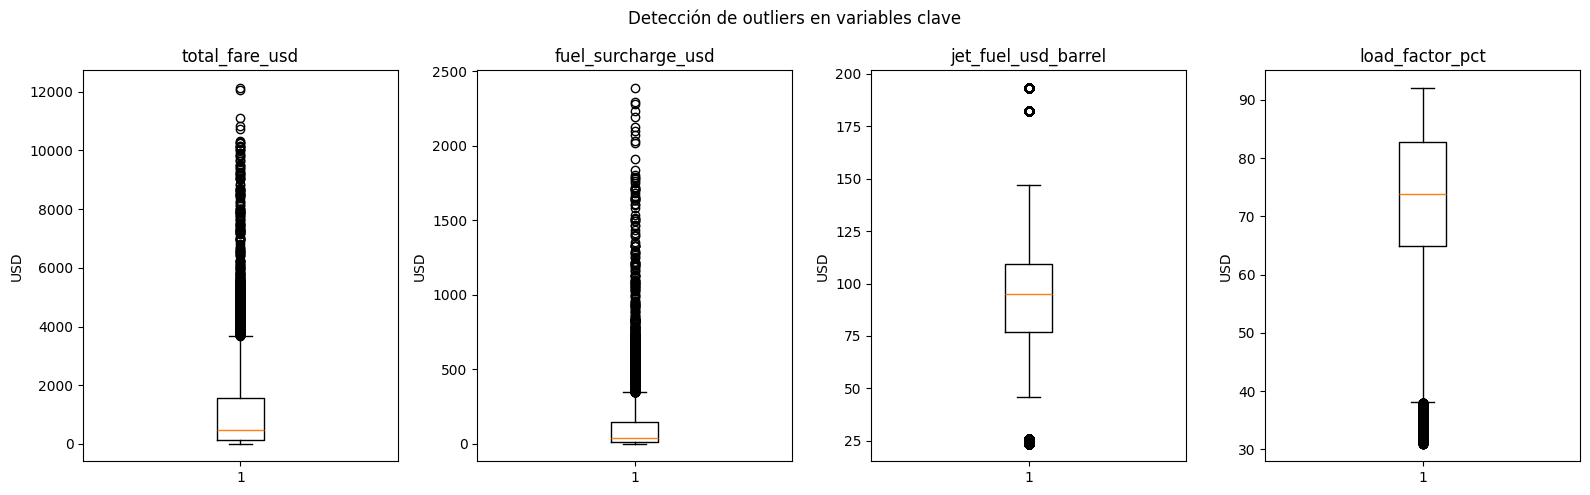

In [ ]:
# Visualizar outliers en variables financieras clave
columnas_outliers = ['total_fare_usd', 'fuel_surcharge_usd',
                     'jet_fuel_usd_barrel', 'load_factor_pct']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(columnas_outliers):
    axes[i].boxplot(df1[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('USD')

plt.suptitle('Detección de outliers en variables clave')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150)
plt.show()

In [ ]:
# Cuantificar outliers usando método IQR
print("=== Outliers por columna (método IQR) ===")
for col in columnas_outliers:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df1[(df1[col] < Q1 - 1.5 * IQR) |
                   (df1[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers detectados")

=== Outliers por columna (método IQR) ===
total_fare_usd: 1118 outliers detectados
fuel_surcharge_usd: 1220 outliers detectados
jet_fuel_usd_barrel: 825 outliers detectados
load_factor_pct: 1173 outliers detectados


## Outliers detectados

En primer lugar, es preciso resaltar que se eligieron cuatro columnas que representan los ejes centrales del análisis.
La columna relativa a la tarifa final (`total_fare_usd`) nos indica el precio final total del pasaje en dólares.
La columna denominada (`fuel_surcharge_usd') señala el recargo adicional por combustible que las empresas trasladan al pasajero.
La columna nombrada  (`jet_fuel_usd_barrel`) representa el precio del combustible de aviación por barril en dólares.
La columna (`load_factor_pct`) hace referencia al nivel de ocupación como proxy de la demanda.

Los boxplots permiten visualizar de forma inmediata que `total_fare_usd`
y `fuel_surcharge_usd` presentan la mayor concentración de valores
atípicos.
La caja (que representa el 50% central de los datos) aparece muy comprimida en la parte inferior del gráfico, mientras que los puntos outliers se extienden considerablemente hacia arriba. Esto indica que la mayoría de los registros se corresponden con coyunturas "estables" del mercado, pero que un subconjunto significativo de ellos dan cuenta de una coyuntura con saltos extraordinarios de precio.  

Sería prematuro arriesgar, en esta instancia preliminar, qué acontecimientos de la geopolítica internacional causaron de dichos valores atípocos. Sin embargo, considerando que el dataset cubre períodos de alta volatilidad en materia energética, podríamos intuir que estos outliers responden a
eventos de crisis energética y no a "errores de carga". Por este motivo, serán conservados en el dataset. Su interpretación y origen serán abordados en profundidad en la etapa de exploración y visualización.

##Estandarizar fechas, categorías y unidades

In [ ]:
# Convertir month a datetime
df1['month'] = pd.to_datetime(df1['month'])
print(f"Tipo de 'month': {df1['month'].dtype}")
print(f"Rango: {df1['month'].min()} → {df1['month'].max()}")

Tipo de 'month': datetime64[ns]
Rango: 2019-01-01 00:00:00 → 2026-03-01 00:00:00


In [ ]:
# Estandarizar texto: sin espacios extra ni mayúsculas inconsistentes
columnas_texto = ['conflict_phase', 'airline', 'country',
                  'region', 'airline_type', 'route_class']

for col in columnas_texto:
    df1[col] = df1[col].str.strip()

# Verificar valores únicos por columna categórica
for col in columnas_texto:
    print(f"\n{col}: {df1[col].unique()}")


conflict_phase: ['Línea de Base Prepandémica' 'Colapso COVID-19' 'Recuperación y Repunte'
 'Shock Guerra de Ucrania' 'Estabilización' 'Conflicto Gaza-Israel'
 'Escalada Pre-Irán' 'Conflicto Bélico EEUU-Irán']

airline: ['ANA' 'Air Arabia' 'Air Arabia Abu Dhabi' 'Air France' 'Air India'
 'American Airlines' 'British Airways' 'Cathay Pacific' 'Delta Air Lines'
 'EgyptAir' 'Emirates' 'Ethiopian Airlines' 'Etihad Airways' 'Gulf Air'
 'IndiGo' 'Japan Airlines' 'KLM' 'Korean Air' 'Kuwait Airways' 'Lufthansa'
 'Malaysia Airlines' 'Oman Air' 'Qatar Airways' 'Ryanair' 'Saudia'
 'Singapore Airlines' 'Southwest Airlines' 'Thai Airways'
 'Turkish Airlines' 'United Airlines' 'easyJet' 'flydubai' 'flynas']

country: ['Japan' 'UAE' 'France' 'India' 'USA' 'UK' 'Hong Kong' 'Egypt' 'Ethiopia'
 'Bahrain' 'Netherlands' 'South Korea' 'Kuwait' 'Germany' 'Malaysia'
 'Oman' 'Qatar' 'Ireland' 'Saudi Arabia' 'Singapore' 'Thailand' 'Turkey']

region: ['Asia' 'Middle East' 'Europe' 'North America' 'Africa']

air

In [ ]:
# Confirmar que las columnas numéricas están en rangos esperados
print("=== Rangos de variables numéricas ===")
columnas_numericas = ['base_fare_usd', 'fuel_surcharge_usd',
                      'total_fare_usd', 'jet_fuel_usd_barrel',
                      'brent_crude_usd', 'load_factor_pct',
                      'fuel_cost_pct_opex']

for col in columnas_numericas:
    print(f"{col}: min={df1[col].min():.2f} | max={df1[col].max():.2f}")


=== Rangos de variables numéricas ===
base_fare_usd: min=11.80 | max=8717.68
fuel_surcharge_usd: min=0.19 | max=2388.26
total_fare_usd: min=13.89 | max=12126.26
jet_fuel_usd_barrel: min=23.69 | max=193.20
brent_crude_usd: min=20.55 | max=169.08
load_factor_pct: min=31.00 | max=92.00
fuel_cost_pct_opex: min=0.05 | max=0.73


In [ ]:
# Resumen del dataset limpio
print("=== Dataset limpio ===")
print(f"Filas: {df1.shape[0]}")
print(f"Columnas: {df1.shape[1]}")
print(f"Nulos restantes: {df1.isnull().sum().sum()}")
print("\nColumnas finales:")
print(df1.columns.tolist())

=== Dataset limpio ===
Filas: 14355
Columnas: 17
Nulos restantes: 1980

Columnas finales:
['month', 'conflict_phase', 'airline', 'country', 'region', 'airline_type', 'route_class', 'avg_route_km', 'base_fare_usd', 'fuel_surcharge_usd', 'taxes_fees_usd', 'total_fare_usd', 'brent_crude_usd', 'jet_fuel_usd_barrel', 'load_factor_pct', 'fuel_cost_pct_opex', 'yoy_price_change_pct']


**Dataset limpio final:**
- Filas: 14.355 (sin eliminaciones)
- Columnas: 17 (se eliminó `iata_code` por redundancia)
- Nulos restantes: 1.980, correspondientes exclusivamente
  a `yoy_price_change_pct`, justificados por ausencia de
  año anterior para comparar. No requieren imputación.

# Exploración y visualización

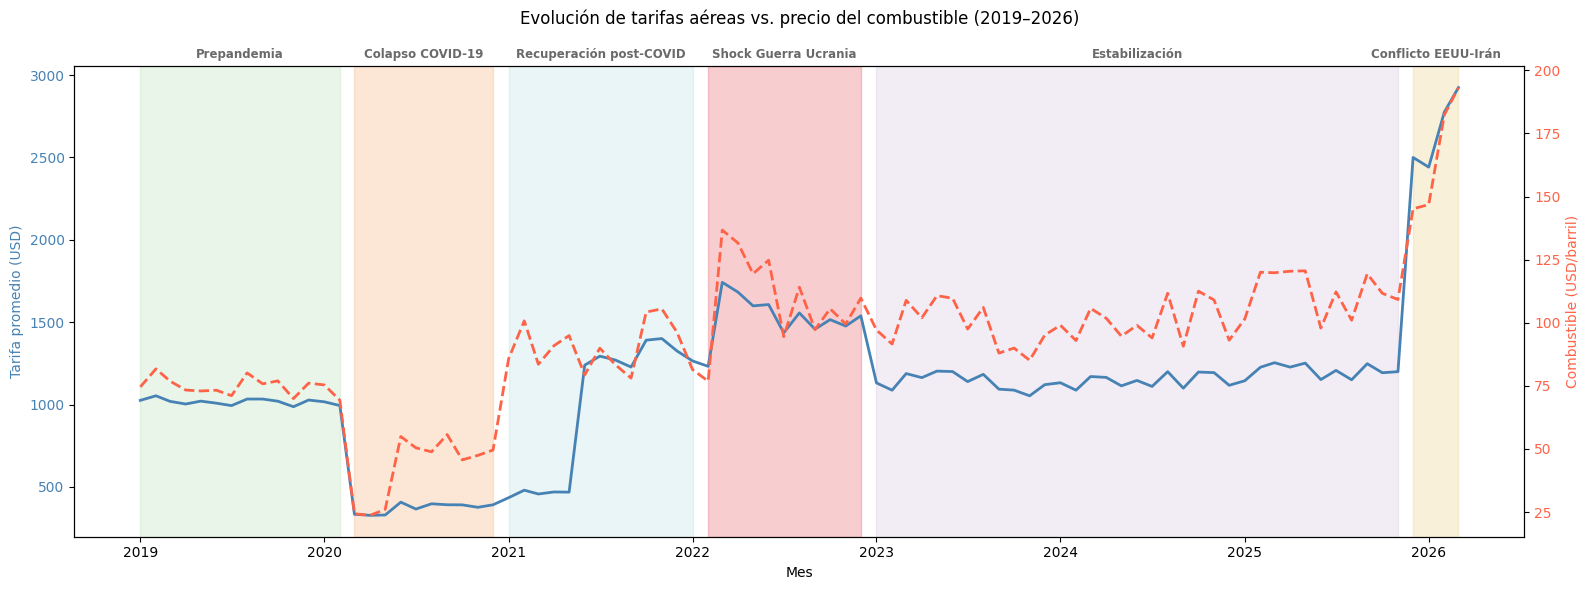

In [ ]:
#Gráfico 1: Evolución de tarifas vs. combustible con bandas de fases geopolíticas y etiquetas arriba
df_monthly = df1.groupby('month')[['total_fare_usd', 'jet_fuel_usd_barrel']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# Bandas de fases geopolíticas
fases = [
    ('2019-01', '2020-02', '#a8d8a8', 'Prepandemia'),
    ('2020-03', '2020-12', '#f4a261', 'Colapso COVID-19'),
    ('2021-01', '2022-01', '#a8dadc', 'Recuperación post-COVID'),
    ('2022-02', '2022-12', '#e63946', 'Shock Guerra Ucrania'),
    ('2023-01', '2025-11', '#cdb4db', 'Estabilización'),
    ('2025-12', '2026-03', '#e9c46a', 'Conflicto EEUU-Irán'),
]

for inicio, fin, color, etiqueta in fases:
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin),
                alpha=0.25, color=color)
    centro = pd.Timestamp(inicio) + (pd.Timestamp(fin) - pd.Timestamp(inicio)) / 2
    ax1.annotate(etiqueta,
                 xy=(centro, 1.01),
                 xycoords=('data', 'axes fraction'),
                 ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold', color='dimgray',
                 annotation_clip=False)

# Líneas principales
ax1.set_xlabel('Mes')
ax1.set_ylabel('Tarifa promedio (USD)', color='steelblue')
ax1.plot(df_monthly['month'], df_monthly['total_fare_usd'],
         color='steelblue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Combustible (USD/barril)', color='tomato')
ax2.plot(df_monthly['month'], df_monthly['jet_fuel_usd_barrel'],
         color='tomato', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Evolución de tarifas aéreas vs. precio del combustible (2019–2026)', pad=30)
fig.tight_layout()
plt.savefig('grafico1_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretación del gráfico de evolución de tarifas aéreas vs. precio del combustible (2019–2026)

El gráfico muestra una relación clara —aunque no perfectamente lineal— entre el precio del combustible (línea roja) y las tarifas aéreas promedio (línea azul) entre 2019 y 2026.

Se puede dividir en cinco momentos.

1. Pre-COVID -es decir entre 2019 e inicios 2020-:
Ambas variables se mantienen estables, con tarifas en torno a 1.000 dls para los vuelos y el combustible cerca de $75 por barril.

2. Colapso COVID-19: Hay un colapso simultáneo, que exhibe una fuerte caída de ambas curvas. El combustible cae a 25 dls, mientras que las tarifas lo hacen al 300/400 dls. Esto, producto del cierre casi total del tráfico aéreo.

3. Recuperación post COVID-19: se inicia una recuperación gradual de ambos precios, aunque el combustible sube más rápido que las tarifas. Esto nos permite presuponer que, en un principio, las aerolíneas absorbieron parte del costo energético, sin trasladarlo en modo directo al pasajero. Más adelante, a mediados del 2021, las tarifas aumentaron en modo significativo, emparejándose con el precio del combustible.

4. Shock Guerra de Ucrania -iniciada el 24 febrero del 2022-: hay un salto vertiginoso en el precio del combustible, acompañado en menor medida por un incremento en el precio de las tarifas. Nuevamente, el precio del combustible se incrementa con mayor rapidez al precio de las tarifas aéreas. A mediados del 2022 vuelven a compaginarse, para volver a desacoplarse al final de dicho año. Desde principios del 2023 hasta fines del 2025 hubo estabilidad de ambos precios, con el combustible fluctuando entre los 80-110 dls y las tarifas entre 1000 dls y 1200 dls.

5. Estabilización: Estabilización (2023–2025): Desde principios de 2023 hasta
fines de 2025 se observa un período de relativa calma. El combustible fluctúa entre los 80 dls y 110 dls por barril, sin picos abruptos, mientras que las tarifas se mantienen en un rango estable de entre 1.000 dls y 1.200 dls. Esta fase refleja un mercado aéreo que logró absorber los shocks anteriores y recuperar cierto equilibrio operativo, con una relación entre combustible
y tarifa más predecible y acoplada que en las etapas previas.

6. Guerra Estados Unidos - Irán (cierre del estrecho de Ormuz): A partir de febrero del año corriente se observa una fuerte suba del combustible, que llega hasta 200 dls, mientras que las tarifas suben también en forma exponencial, llegando incluso a superar los 3000 dls. Se trata, para ambas variables, de los picos más elevados de la serie.

Puede decirse que la relación entre combustible y tarifa es positiva
pero no inmediata ni proporcional. Los shocks geopolíticos actúan como amplificadores que desacoplan temporalmente ambas variables.

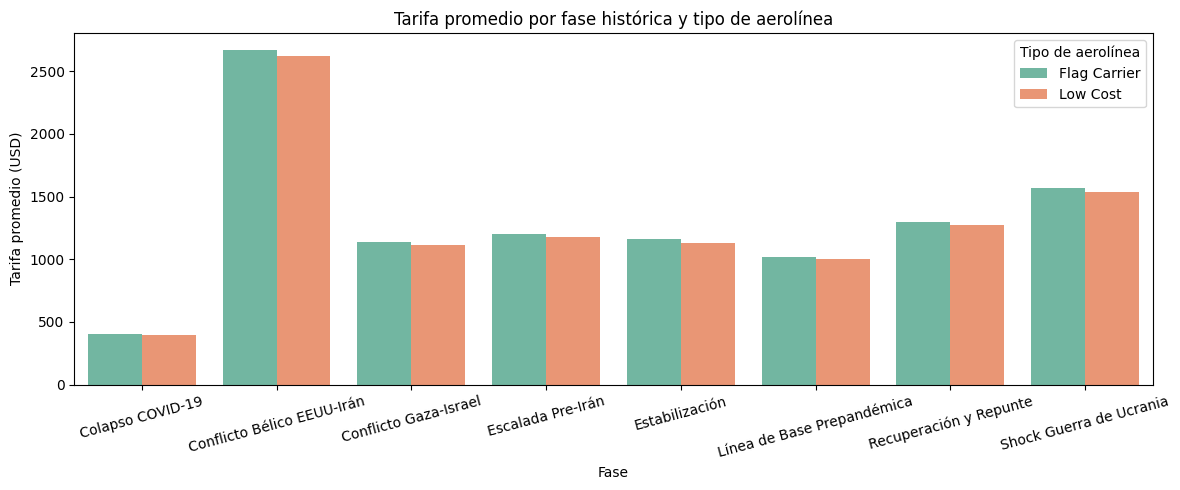

In [ ]:
# Gráfico 2: Tarifa promedio por fase y tipo de aerolínea
plt.figure(figsize=(12, 5))

df_fase = df1.groupby(['conflict_phase', 'airline_type'])['total_fare_usd'].mean().reset_index()

sns.barplot(data=df_fase, x='conflict_phase', y='total_fare_usd',
            hue='airline_type', palette='Set2')

plt.title('Tarifa promedio por fase histórica y tipo de aerolínea')
plt.xlabel('Fase')
plt.ylabel('Tarifa promedio (USD)')
plt.xticks(rotation=15)
plt.legend(title='Tipo de aerolínea')
plt.tight_layout()
plt.savefig('grafico2_fases.png', dpi=150)
plt.show()

## Interpretación del gráfico que evalúa tarifa promedio por fase histórica y tipo de aerolínea

El gráfico compara las tarifas promedio de Flag Carriers y Low Cost
en cada una de las 8 fases del dataset.

El hallazgo más llamativo es que las diferencias entre ambos tipos
de aerolínea son prácticamente inexistentes en todas las fases:
las barras verde y naranja alcanzan casi la misma altura en cada
grupo. Esto indica que frente a shocks energéticos o geopolíticos,
el modelo de negocio pierde relevancia como variable diferenciadora
de precios.

En cuanto a la evolución por fases, el Colapso COVID-19 registra
las tarifas más bajas 400 dls, no por decisión comercial sino por
el colapso de la demanda global. La línea de base pre-pandemia muestra
los valores más bajos en condiciones normales de mercado 1.000 dls.
El conflicto entre Estados Unidos e Irán es la fase más cara de toda la serie,
superando los 2.600 dls , como consecuencia directa del cierre del
Estrecho de Ormuz y el encarecimiento extremo del combustible.

En síntesis, puede decirse que los shocks geopolíticos influyen en la determinación de los precios, pero no hay una variación significativa entre las Flag Carriers y las Low Cost, en tanto que se observa que ambos modelos de negocio convergen al mismo precio.


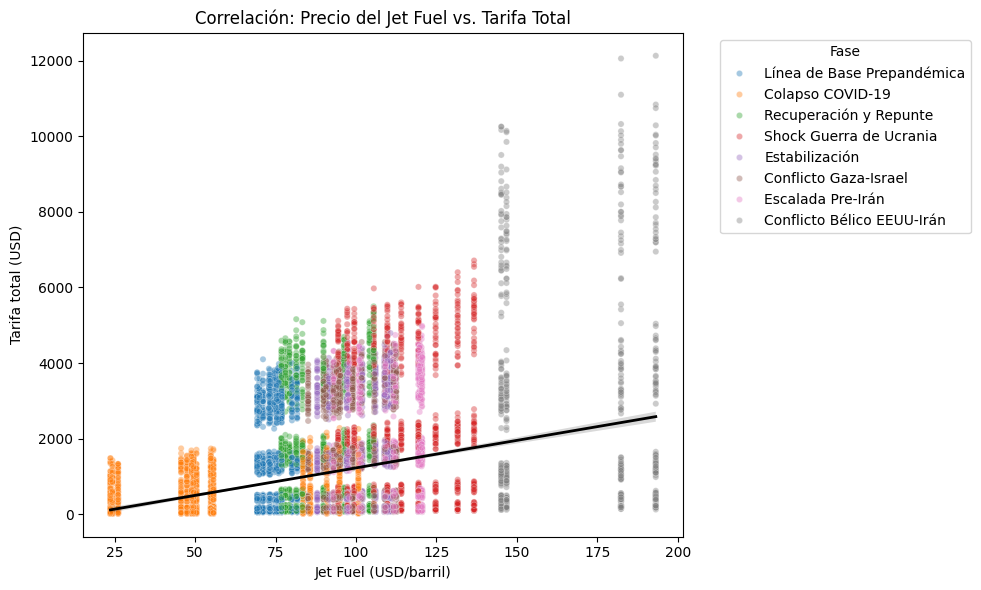

In [ ]:
# Gráfico 3: Correlación jet fuel vs tarifa total
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df1, x='jet_fuel_usd_barrel', y='total_fare_usd',
                hue='conflict_phase', alpha=0.4, s=20, palette='tab10')

sns.regplot(data=df1, x='jet_fuel_usd_barrel', y='total_fare_usd',
            scatter=False, color='black',
            line_kws={'linewidth': 2})

plt.title('Correlación: Precio del Jet Fuel vs. Tarifa Total')
plt.xlabel('Jet Fuel (USD/barril)')
plt.ylabel('Tarifa total (USD)')
plt.legend(title='Fase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('grafico3_correlacion.png', dpi=150)
plt.show()

## Interpretación del gráfico de correlación entre el precio del Jet Fuel vs. Tarifa Total

Cada punto del gráfico representa un registro del dataset,
ubicado según el precio del combustible (eje X) y la tarifa
total pagada por el pasajero (eje Y). Los colores identifican
cada fase histórica y la línea negra muestra la tendencia general.

Hay una tendencia positiva que confirma que a mayor precio del combustible,
mayor tarifa. Sin embargo, la dispersión vertical es el dato
más revelador, ya que con un mismo precio de jet fuel hay tarifas
que pueden variar hasta diez veces según la aerolínea, la ruta
y el contexto geopolítico. Esto indica que el combustible
es un factor influyente pero no determinante per sé.

Cada fase ocupa una franja horizontal diferenciada. El Colapso COVID-19
(naranja) se concentra en la zona de combustible barato 25 dls
pero con tarifas igualmente bajas, porque la demanda colapsó
independientemente del costo energético. Las fases intermedias
como Recuperación y Repunte, y Shcok Guerra de Ukrania muestran nubes de
puntos que escalan progresivamente hacia la derecha y hacia
arriba. La fase relativ a la Guerra Estados Unidos e Irán (gris) es la más dispersa; está concentrada en 180-200 dls/barril, presenta tarifas que van desde
500 dls hasta 12.000 dls, evidenciando estrategias muy distintas
entre aerolíneas ante el mismo shock energético.

En definitiva, el combustible explica la dirección del precio, pero no su magnitud ni su dispersión; es decir, no es un factor que pueda predecir aritméticamente el comportamiento de las tarifas. Habría que contextualizar este escenario con Variables como la demanda, la estrategia comercial de cada aerolínea, etc.

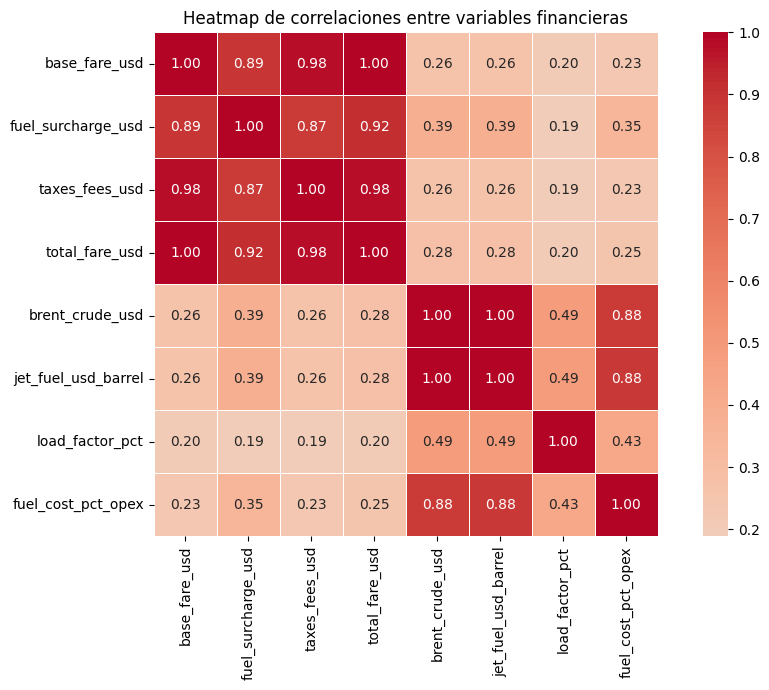

In [ ]:
# Gráfico 4: Heatmap de correlaciones
plt.figure(figsize=(10, 7))

columnas_numericas = ['base_fare_usd', 'fuel_surcharge_usd', 'taxes_fees_usd',
                      'total_fare_usd', 'brent_crude_usd', 'jet_fuel_usd_barrel',
                      'load_factor_pct', 'fuel_cost_pct_opex']

correlacion = df1[columnas_numericas].corr()

sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)

plt.title('Heatmap de correlaciones entre variables financieras')
plt.tight_layout()
plt.savefig('grafico4_heatmap.png', dpi=150)
plt.show()

##Interpretación del heatmap de correlaciones entre variables financieras

El gráfico permite identificar dos bloques de correlación bien
diferenciados. El primero agrupa las variables de tarifa:
`base_fare_usd`, `taxes_fees_usd` y `total_fare_usd` presentan
correlaciones de 0.98 a 1.00 entre sí, lo que indica que el
precio final del pasaje está casi enteramente determinado por
la tarifa base. El recargo por combustible (`fuel_surcharge_usd`)
también se integra a este bloque con valores de 0.87 a 0.92,
confirmando que las aerolíneas lo ajustan proporcionalmente
al precio base y no de forma independiente.

El segundo bloque agrupa las variables energéticas: `brent_crude_usd`
y `jet_fuel_usd_barrel` tienen correlación de 1.00, lo que
los convierte en variables prácticamente idénticas. A su vez,
`fuel_cost_pct_opex` se correlaciona con ambas en 0.88,
mostrando que el peso del combustible en los costos operativos
sigue directamente al precio del petróleo.

El dato más relevante para la pregunta de investigación es
la correlación entre `jet_fuel_usd_barrel` y `total_fare_usd`,
que alcanza apenas 0.28. Esto significa que el precio del
combustible explica solo el 28% de la variación en las tarifas,
controvirtiendo así la premisa de que el petróleo es el principal
determinante del precio del pasaje aéreo.

Cuando se observa el bloque de variables tarifarias —tarifa base, impuestos, recargo por combustible y tarifa total— lo que aparece no es solo una alta correlación, sino algo más fuerte: una colinealidad casi perfecta. Esto implica que estas variables no se mueven de forma independiente, sino que están funcionalmente atadas entre sí. La tarifa total no emerge como resultado de múltiples decisiones autónomas, sino como una agregación casi mecánica de componentes que escalan juntos. Desde el punto de vista económico, esto sugiere que las aerolíneas aplican un esquema de traslado proporcional de costos, donde los aumentos en cualquiera de los componentes (incluido el combustible) terminan reflejándose en el precio final sin que haya una absorción diferencial en alguna parte de la estructura tarifaria. Es decir, no hay evidencia de estrategias consistentes de subsidio cruzado interno entre componentes del precio.

En lo que concierne al bloque energético ocurre algo distinto pero igualmente revelador; la correlación perfecta entre el precio del crudo Brent y el jet fuel indica que, a efectos analíticos, ambas variables son redundantes. Representan el mismo proceso subyacente, que es la dinámica del mercado internacional de petróleo. Esto no es menor, porque elimina la posibilidad de tratarlas como factores independientes en un modelo explicativo. A su vez, el hecho de que el porcentaje del gasto operativo destinado al combustible se mueva casi en sincronía con estos precios muestra una alta rigidez estructural en los costos de las aerolíneas. No hay evidencia de desacople significativo mediante eficiencia, sustitución o cobertura financiera sostenida en el tiempo. En términos prácticos, el sistema operativo de las aerolíneas está fuertemente indexado al precio de la energía.

Ahora bien, el punto más interesante —y en cierto sentido contraintuitivo— aparece cuando se cruzan ambos bloques. A pesar de que el combustible es un componente crítico de costos y de que su precio está claramente identificado y medido, su correlación con la tarifa total es baja. Esto rompe la expectativa lineal de que un aumento en costos debería trasladarse directamente a precios. Lo que el heatmap está mostrando es que entre el costo energético y el precio final hay una serie de variables intervinientes que diluyen, modulan o incluso bloquean esa relación directa. Entre ellas, podríamos intuir, la demanda, las restricciones de oferta, la segmentación del mercado y, por supuesto, el contexto geopolítico. Estas variables introducen ruido y heterogeneidad en la formación de precios, haciendo que el sistema no responda de manera mecánica a los cambios en los costos.

Desde una perspectiva más técnica, esto implica que el precio del combustible tiene capacidad explicativa sobre la dirección del movimiento de las tarifas (tiende a empujar hacia arriba o hacia abajo), pero no sobre su magnitud ni su dispersión. Es decir, funciona como una condición necesaria pero no suficiente. La baja correlación observada no invalida su importancia, sino que señala que su efecto está mediado por un sistema más complejo de determinación de precios.

En definitiva, el aporte del heatmap no es descriptivo sino epistemológico dentro del análisis. Permite separar lo que es estructura de lo que es dinámica: por un lado, identifica relaciones casi determinísticas (como la composición de la tarifa o la vinculación entre precios energéticos), y por otro, evidencia dónde esas relaciones se rompen cuando entran en juego factores de mercado. Gracias a esto, la conclusión de que el combustible no determina directamente las tarifas deja de ser una inferencia intuitiva basada en gráficos de tendencia y pasa a ser una afirmación respaldada por la propia arquitectura estadística de los datos



## Conclusiones generales

El análisis exploratorio del dataset *Airline Ticket Prices vs Oil &
Fuel Costs* nos permitió responder la pregunta de investigación planteada al inicio de este proyecto. A continuación, expondremos los hallazgos principales:

1. **La relación entre combustible y tarifa es positiva pero no directamente
proporcional.** El heatmap confirmó una correlación de apenas 0.28
entre el precio del jet fuel y la tarifa final, lo que indica que otros factores —demanda, contexto geopolítico, estrategia comercial—
inciden como variables moderadoras.

2. **Los shocks geopolíticos son el principal amplificador de precios.**
Las fases de crisis (COVID-19, Guerra de Ucrania, Conflicto EEUU-Irán y consiguiente clausura del Estrecho de Ormuz) generaron variaciones de tarifa que superaron con creces el precio del combustible "per sé".

3. **El modelo de negocio no es una variable diferenciadora en crisis.**
Flag Carriers y Low Cost convergieron hacia tarifas similares en todas
las fases, sugiriendo que ante shocks energéticos globales, el tipo
de aerolínea pierde relevancia como factor de precio.

4. **El período de estabilización (2023–2025) confirma que el mercado
aéreo puede recuperar equilibrio.**
Cuando el contexto geopolítico se estabiliza, la relación entre combustible y tarifa se vuelve más predecible y "armoniosa".

5. **Los outliers detectados fueron los registros más valiosos del dataset.** Corresponden a fases de crisis extrema y fueron conservados para preservar la integridad del análisis.

## Pasos finales

- Abordaremos la construcción de un dashboard interactivo en Power BI con KPIs
  y panel de filtros que segmenten por región, tipo de aerolínea y fase.
- Publicremos el proyecto en GitHub con una estructura organizada de carpetas, README completo y enlaces funcionales al dataset y al notebook.

In [ ]:
# Exportar dataset limpio para usar en Power BI
df1.to_csv('airline_ticket_prices_limpio.csv', index=False)
print("✅ Dataset limpio exportado correctamente")
print(f"Filas: {df1.shape[0]} | Columnas: {df1.shape[1]}")

✅ Dataset limpio exportado correctamente
Filas: 14355 | Columnas: 17


In [ ]:
# Copiar el dataset limpio al Drive
import shutil
shutil.copy(
    'airline_ticket_prices_limpio.csv',
    '/content/drive/MyDrive/Colab Notebooks/airline_ticket_prices_limpio.csv'
)
print("✅ Archivo guardado en Google Drive")

✅ Archivo guardado en Google Drive
